future work for the data scenarios
- create better data

future work for the features table
- seasonality feature
- rolling average feature


In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [11]:
df = pd.read_parquet('../data/vietnam_to_us.parquet').reset_index(drop=True)
df.tail()

,origin_country,us_destination_state,us_destination_postal_code,delivery_status,projected_days,actual_days,order_date
752,Vietnam,TX,78201.0,Late delivery,4,6,2018-02-04
753,Vietnam,CT,6810.0,Late delivery,4,5,2018-02-04
754,Vietnam,PR,725.0,Late delivery,4,6,2018-02-05
755,Vietnam,MO,63021.0,Late delivery,4,6,2018-02-05
756,Vietnam,PR,725.0,Late delivery,2,6,2018-02-06


In [12]:
df['us_destination_state'].value_counts().reset_index().sort_values('us_destination_state')

,us_destination_state,count
27,AR,2
9,AZ,16
1,CA,100
17,CO,9
12,CT,11
16,DC,9
6,FL,29
10,GA,15
22,HI,5
25,ID,3


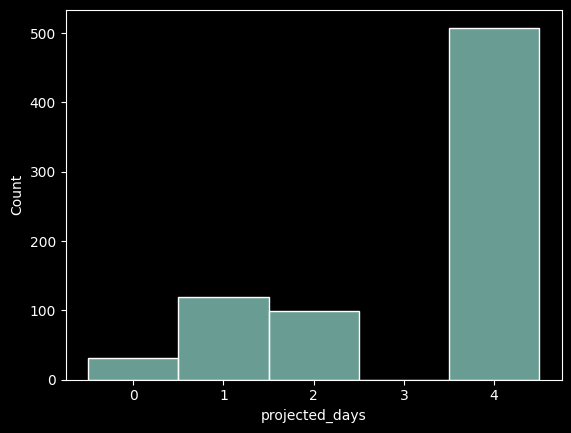

In [13]:
# To center the histogram bars around the integer values
vals = df['projected_days']
bins = np.arange(vals.min() - 0.5, vals.max() + 0.5 + 1e-8, 1)  # edges like -0.5,0.5,1.5,...

# Plot the histogram
sns.histplot(data=df, x="projected_days", bins=bins)
plt.xticks(np.arange(vals.min(), vals.max() + 1))
plt.show()

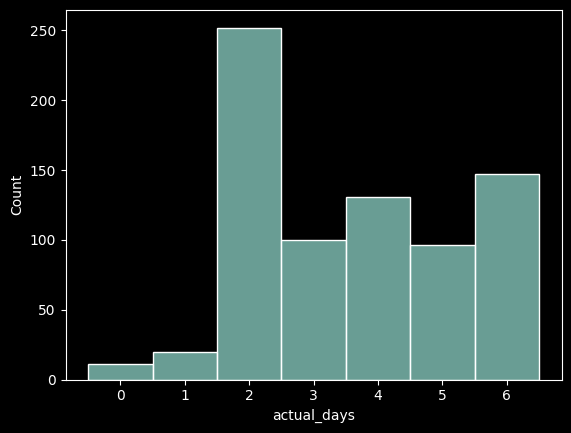

In [14]:
# To center the histogram bars around the integer values
vals = df['actual_days']
bins = np.arange(vals.min() - 0.5, vals.max() + 0.5 + 1e-8, 1)  # edges like -0.5,0.5,1.5,...

# Plot the histogram
sns.histplot(data=df, x="actual_days", bins=bins)
plt.xticks(np.arange(vals.min(), vals.max() + 1))
plt.show()

In [15]:
df['actual_days'].describe()

count    757.000000
mean       3.579921
std        1.632351
min        0.000000
25%        2.000000
50%        3.000000
75%        5.000000
max        6.000000
Name: actual_days, dtype: float64

In [16]:
df[['origin_country', 'us_destination_state', 'projected_days', 'actual_days', 'order_date']]\
    .to_parquet('../data/features_table.parquet')

In [17]:
# df[['origin_country', 'us_destination_state', 'projected_days', 'actual_days', 'order_date']]\
#     .to_csv('../data/features_table.csv', index=False)